In [45]:
import pandas as pd
import seaborn as sns

# Cellmates benchmark with DICE and MEDICC

In [7]:
input = "../../results/statsX.csv"
df = pd.read_csv(input)
df.head()

,dat_path,dataset,seed,n_cells,n_states,n_clones,n_sites,lambda,ru_mse,uv_mse,...,cn_mad,medicc2_nrf,dice_nrf,medicc2_f1,dice_f1,boundary_noise,jitter_noise,n_clones_gen,mean_cnas_per_edge,cn_length_mean
0,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Ds1_0,0,50,7,1,2000,2.0,0.000007,1.322602e-07,...,NaN,0.104167,0.177083,1.0,1.0,NaN,NaN,NaN,NaN,NaN
1,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Ds1_0,0,50,7,1,2000,2.0,0.000008,1.729849e-07,...,NaN,0.145833,0.281250,1.0,1.0,0.0,0.0,0.0,2.0,5000000.0
2,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Ds1_0,1,50,7,1,2000,2.0,0.000002,1.658277e-06,...,NaN,0.104167,0.114583,1.0,1.0,NaN,NaN,NaN,NaN,NaN
3,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Ds1_0,1,50,7,1,2000,2.0,0.000006,7.369829e-07,...,NaN,0.104167,0.114583,1.0,1.0,NaN,NaN,NaN,NaN,NaN
4,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Ds1_0,2,50,7,1,2000,2.0,0.000009,3.857295e-07,...,NaN,0.083333,0.135417,1.0,1.0,NaN,NaN,NaN,NaN,NaN


In [50]:
df.columns

Index(['dat_path', 'dataset', 'seed', 'n_cells', 'n_states', 'n_clones',
       'n_sites', 'lambda', 'ru_mse', 'uv_mse', 'uw_mse', 'rf', 'urf', 'nrf',
       'f1_gt', 'f1_em', 'wgd', 'gt_ties', 'data_type', 'cn_mad',
       'medicc2_nrf', 'dice_nrf', 'medicc2_f1', 'dice_f1', 'boundary_noise',
       'jitter_noise', 'n_clones_gen', 'mean_cnas_per_edge', 'cn_length_mean'],
      dtype='object')

In [8]:
df[df['boundary_noise'].isna()]['dataset']

0      Ds1_0
2      Ds1_0
3      Ds1_0
4      Ds1_0
5      Ds1_0
13     Ds2_0
14     Ds2_0
15     Ds2_0
16     Ds2_0
17     Ds2_0
26     Ds3_0
28     Ds3_0
30     Ds3_0
78     Fs1_0
80     Fs1_0
82     Fs1_0
91     Fs2_0
92     Fs2_0
93     Fs2_0
94     Fs2_0
95     Fs2_0
96     Fs2_0
97     Fs3_0
98     Fs3_0
99     Fs3_0
100    Fs3_0
101    Fs3_0
102    Fs3_0
110    Fs4_0
111    Fs4_0
112    Fs4_0
113    Fs4_0
114    Fs4_0
115    Fs4_0
116    Fs5_0
118    Fs5_0
120    Fs5_0
121    Fs5_0
129    Fs6_0
130    Fs6_0
131    Fs6_0
132    Fs6_0
133    Fs6_0
134    Fs6_0
135    Fs7_0
137    Fs7_0
139    Fs7_0
148    Fs8_0
149    Fs8_0
150    Fs8_0
151    Fs8_0
152    Fs8_0
153    Fs8_0
Name: dataset, dtype: object

In [91]:
dataset_name = 'Ds4_0'

In [92]:
df[df['dataset'] == dataset_name][['boundary_noise', 'jitter_noise', 'n_clones_gen', 'mean_cnas_per_edge', 'cn_length_mean']]

,boundary_noise,jitter_noise,n_clones_gen,mean_cnas_per_edge,cn_length_mean


In [93]:
# correct missing data
# df.loc[df['dataset'] == dataset_name, 'boundary_noise']     = 0
# df.loc[df['dataset'] == dataset_name, 'jitter_noise']       = 0
# df.loc[df['dataset'] == dataset_name, 'n_clones_gen']       = 0
# df.loc[df['dataset'] == dataset_name, 'cn_length_mean']     = 5000000
# df.loc[df['dataset'] == dataset_name, 'mean_cnas_per_edge'] = 10
# df.to_csv('../../results/statsX.csv')


In [ ]:
# melt data (method: cellmates, dice, medicc2  | metric nrf, f1)
dfm_f1 = pd.melt(
    id_vars=['seed', 'data_type', 'wgd', ''],
    value_vars=['f1_gt', 'f1_em', 'medicc2_f1', 'dice_f1'],
    var_name='f1',
    value_name='value'
)


## F data

In [44]:
Fdf = df[df['dataset'].apply(lambda x: "F" in x)]
Fdf.head()

,dat_path,dataset,seed,n_cells,n_states,n_clones,n_sites,lambda,ru_mse,uv_mse,...,cn_mad,medicc2_nrf,dice_nrf,medicc2_f1,dice_f1,boundary_noise,jitter_noise,n_clones_gen,mean_cnas_per_edge,cn_length_mean
78,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Fs1_0,0,50,7,1,2000,2.0,0.000010,1.065395e-07,...,NaN,0.520833,0.427083,1.0,1.0,0.05,0.02,0.0,5000000.0,2.0
79,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Fs1_0,0,50,7,1,2000,2.0,0.000013,5.745267e-07,...,NaN,0.541667,0.197917,1.0,1.0,0.05,0.02,0.0,5000000.0,2.0
80,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Fs1_0,1,50,7,1,2000,2.0,0.000012,1.274388e-07,...,NaN,0.583333,0.281250,1.0,1.0,0.05,0.02,0.0,5000000.0,2.0
81,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Fs1_0,1,50,7,1,2000,2.0,0.000007,6.067770e-07,...,NaN,0.416667,0.302083,1.0,1.0,0.05,0.02,0.0,5000000.0,2.0
82,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Fs1_0,2,50,7,1,2000,2.0,0.000010,2.160582e-07,...,NaN,0.354167,0.302083,1.0,1.0,0.05,0.02,0.0,5000000.0,2.0


Index(['dat_path', 'dataset', 'seed', 'n_cells', 'n_states', 'n_clones',
       'n_sites', 'lambda', 'ru_mse', 'uv_mse', 'uw_mse', 'rf', 'urf', 'nrf',
       'f1_gt', 'f1_em', 'wgd', 'gt_ties', 'data_type', 'cn_mad',
       'medicc2_nrf', 'dice_nrf', 'medicc2_f1', 'dice_f1', 'boundary_noise',
       'jitter_noise', 'n_clones_gen', 'mean_cnas_per_edge', 'cn_length_mean'],
      dtype='object')


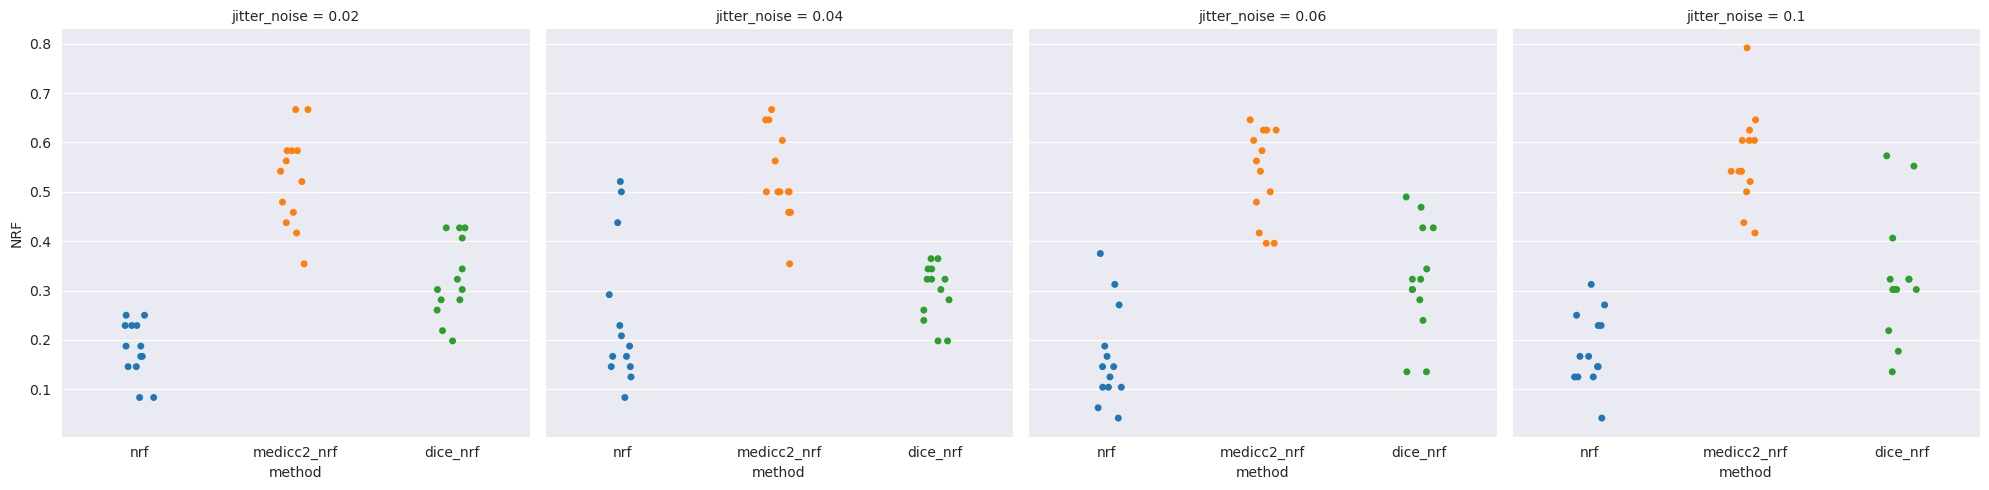

In [55]:
# plot RF score with noise
Fdf_noclone = Fdf[Fdf['n_clones'] == 1]
print(Fdf_noclone.columns)
Fdf_noclone = pd.melt(Fdf_noclone,
    id_vars=['seed', 'jitter_noise', 'boundary_noise', 'dataset'],
    value_vars=['nrf', 'medicc2_nrf', 'dice_nrf'],
    var_name='method',
    value_name='NRF'
)
g = sns.catplot(Fdf_noclone, x='method', y='NRF', hue='method', col='jitter_noise')
 # g = sns.catplot(x='n_cells', y='normalized_rf', hue='method', col='p_change',
 #        data=melt_df, kind='box', height=3, aspect=0.7, palette="Set2")
 #    g.set_axis_labels("N", "Normalized RF")
 #    g.set_titles("p = {col_name}")
 #    sns.move_legend(g, title=None, loc='lower center', ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.1))
 #    # place legend to the bottom right inside the figure and smaller
 #    g.savefig(f"rf_vs_n_cells_facet{suff}.png", dpi=300)


## D data

In [95]:
Ddf = df[df['dataset'].apply(lambda x: x.startswith("Ds"))]
Ddf.head()


,dat_path,dataset,seed,n_cells,n_states,n_clones,n_sites,lambda,ru_mse,uv_mse,...,cn_mad,medicc2_nrf,dice_nrf,medicc2_f1,dice_f1,boundary_noise,jitter_noise,n_clones_gen,mean_cnas_per_edge,cn_length_mean
0,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Ds1_0,0,50,7,1,2000,2.0,0.000007,1.322602e-07,...,NaN,0.104167,0.177083,1.0,1.0,0.0,0.0,0.0,2.0,5000000.0
1,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Ds1_0,0,50,7,1,2000,2.0,0.000008,1.729849e-07,...,NaN,0.145833,0.281250,1.0,1.0,0.0,0.0,0.0,2.0,5000000.0
2,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Ds1_0,1,50,7,1,2000,2.0,0.000002,1.658277e-06,...,NaN,0.104167,0.114583,1.0,1.0,0.0,0.0,0.0,2.0,5000000.0
3,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Ds1_0,1,50,7,1,2000,2.0,0.000006,7.369829e-07,...,NaN,0.104167,0.114583,1.0,1.0,0.0,0.0,0.0,2.0,5000000.0
4,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Ds1_0,2,50,7,1,2000,2.0,0.000009,3.857295e-07,...,NaN,0.083333,0.135417,1.0,1.0,0.0,0.0,0.0,2.0,5000000.0


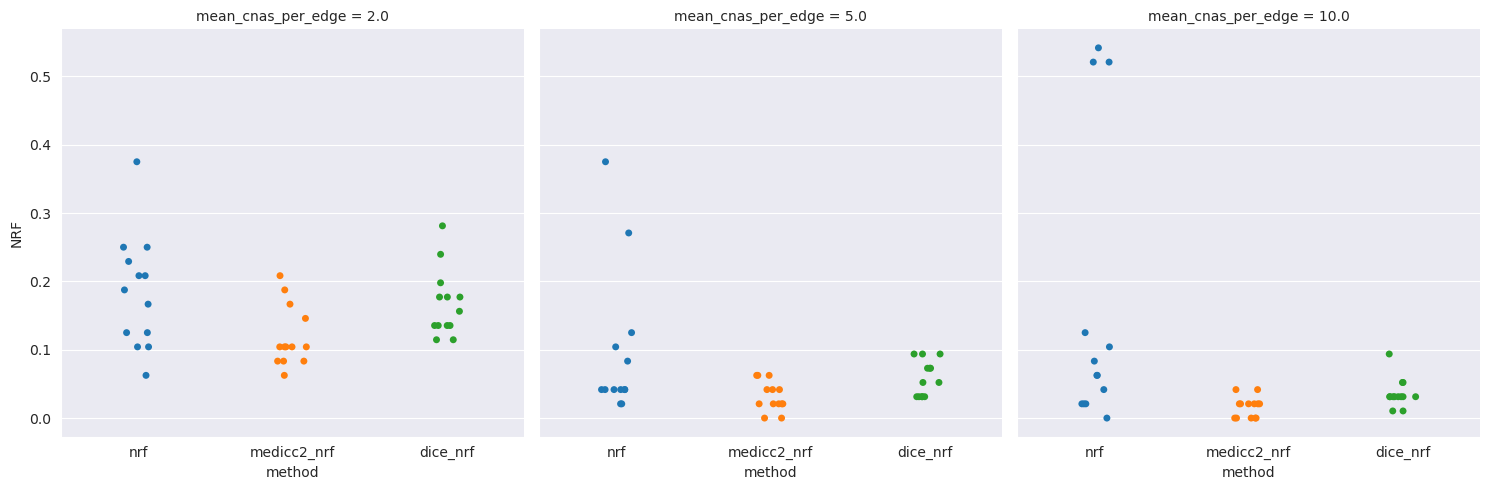

In [96]:
## RF score
DdfM = pd.melt(Ddf,
    id_vars=['seed', 'jitter_noise', 'dataset', 'mean_cnas_per_edge'],
    value_vars=['nrf', 'medicc2_nrf', 'dice_nrf'],
    var_name='method',
    value_name='NRF'
)
g = sns.catplot(DdfM, x='method', y='NRF', hue='method', col='mean_cnas_per_edge')


## Gxs

In [104]:
from itertools import product

,dat_path,dataset,seed,n_cells,n_states,n_clones,n_sites,lambda,ru_mse,uv_mse,...,cn_mad,medicc2_nrf,dice_nrf,medicc2_f1,dice_f1,boundary_noise,jitter_noise,n_clones_gen,mean_cnas_per_edge,cn_length_mean
184,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Gxs1_1,0,50,7,6,600,5.0,0.000072,0.000070,...,NaN,0.145833,0.114583,0.963415,0.930081,0.04,0.1,4.0,5.0,10000000.0
185,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Gxs1_1,1,50,7,6,600,5.0,0.000240,0.000138,...,NaN,0.125000,0.093750,0.963064,0.963064,0.04,0.1,4.0,5.0,10000000.0
186,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Gxs1_1,2,50,7,6,600,5.0,0.000208,0.000110,...,NaN,0.250000,0.156250,0.931746,0.905820,0.04,0.1,4.0,5.0,10000000.0
187,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Gxs1_1,3,50,7,6,600,5.0,0.000140,0.000260,...,NaN,0.333333,0.281250,0.911111,0.902778,0.04,0.1,4.0,5.0,10000000.0
188,/proj/sc_ml/shared/cnasim_data/dice_benchmark_...,Gxs1_1,4,50,7,5,600,5.0,0.000219,0.000123,...,NaN,0.375000,0.177083,0.917576,0.916047,0.04,0.1,4.0,5.0,10000000.0


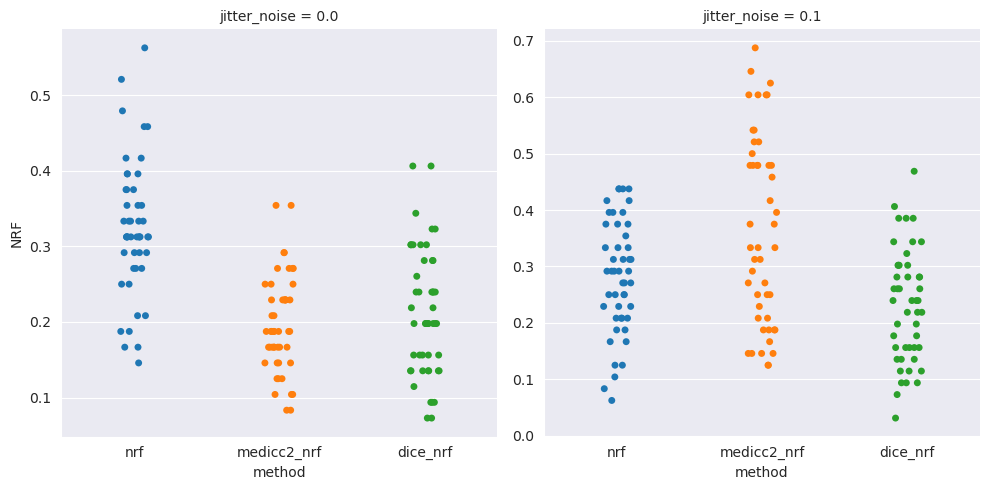

In [111]:
Gxdf = df[df['dataset'].apply(lambda x: x.startswith("Gx"))]
Gxdf = pd.melt(Gxdf,
    id_vars=['seed', 'jitter_noise', 'boundary_noise', 'dataset', 'mean_cnas_per_edge', 'n_clones', 'cn_length_mean'],
    value_vars=['nrf', 'medicc2_nrf', 'dice_nrf'],
    var_name='method',
    value_name='NRF'
)
g = sns.catplot(Gxdf, x='method', y='NRF', hue='method', col='jitter_noise', sharey=False)

In [137]:
sns.set_theme(style="whitegrid")
# Map method labels
method_labels = {'nrf': "Cellmates", 'dice_nrf': "DICE", 'medicc2_nrf': "MEDICC2"}

/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the stripplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


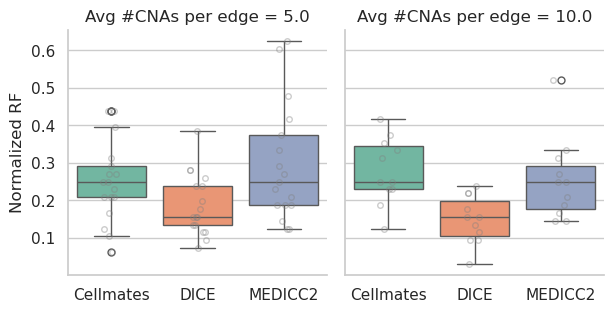

In [188]:

Gxdf = df[df['dataset'].apply(lambda x: x.startswith("Gx"))]
Gxdf = Gxdf[Gxdf['jitter_noise'] > 0]
Gxdf = Gxdf[~Gxdf['mean_cnas_per_edge'].isin([2, 8])]
Gxdf = pd.melt(Gxdf,
    id_vars=['seed', 'jitter_noise', 'boundary_noise', 'dataset', 'mean_cnas_per_edge', 'n_clones', 'cn_length_mean'],
    value_vars=['nrf', 'medicc2_nrf', 'dice_nrf'],
    var_name='method',
    value_name='NRF'
)
method_labels = {'nrf': "Cellmates", 'dice_nrf': "DICE", 'medicc2_nrf': "MEDICC2"}
Gxdf['method'] = Gxdf['method'].map(method_labels).astype('category').cat.set_categories(['Cellmates', 'DICE', 'MEDICC2'], ordered=True)
g = sns.catplot(Gxdf, x='method', y='NRF', hue='method', col='mean_cnas_per_edge', sharey=True, kind='box', palette='Set2', height=3.5, aspect=0.9)
g.map(sns.stripplot, 'method', 'NRF', marker='$\circ$', color='grey', alpha=0.4)

g.set_axis_labels("", "Normalized RF")
g.set_titles("Avg #CNAs per edge = {col_name}")
g.savefig("../../results/rf_benchmark.png", dpi=200)

# g = sns.catplot(Gxdf, x='method', y='NRF', hue='method', col='cn_length_mean', sharey=False)



/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the stripplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


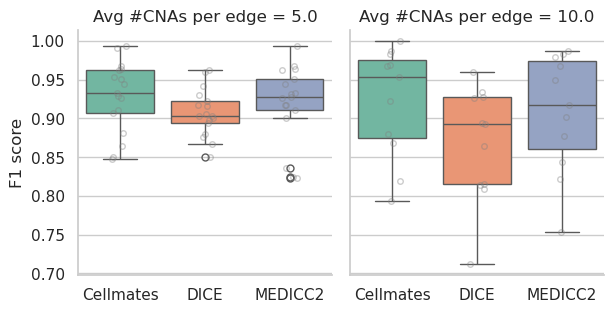

In [189]:
Gxdf = df[df['dataset'].apply(lambda x: x.startswith("Gx"))]
Gxdf = Gxdf[Gxdf['jitter_noise'] > 0]
Gxdf = Gxdf[Gxdf['mean_cnas_per_edge'] > 2]
Gxdf = Gxdf[Gxdf['n_clones'] > 1]
Gxdf = pd.melt(Gxdf,
    id_vars=['seed', 'jitter_noise', 'boundary_noise', 'dataset', 'mean_cnas_per_edge', 'n_clones', 'cn_length_mean'],
    value_vars=['f1_em', 'dice_f1', 'medicc2_f1'],
    var_name='method',
    value_name='F1'
)
method_labels = {'f1_em': "Cellmates", 'dice_f1': "DICE", 'medicc2_f1': "MEDICC2"}
Gxdf['method'] = Gxdf['method'].map(method_labels).astype('category').cat.set_categories(['Cellmates', 'DICE', 'MEDICC2'], ordered=True)
g = sns.catplot(Gxdf, x='method', y='F1', hue='method', col='mean_cnas_per_edge', sharey=True, kind='box', palette='Set2', height=3.5, aspect=.9)
g.map(sns.stripplot, 'method', 'F1', marker='$\circ$', color='grey', alpha=0.4)

g.set_axis_labels("", "F1 score")
g.set_titles("Avg #CNAs per edge = {col_name}")
g.savefig("../../results/f1_benchmark.png", dpi=200)



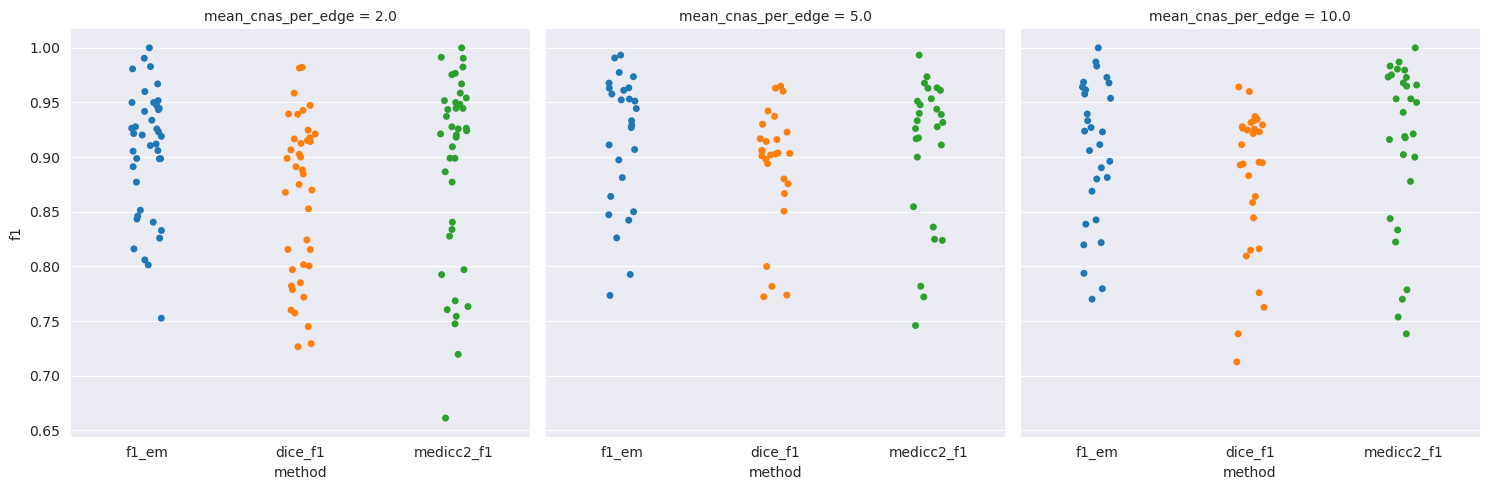

In [117]:
## F1 score
Gxdf = df[df['dataset'].apply(lambda x: x.startswith("Gx"))]
Gxdf = pd.melt(Gxdf,
    id_vars=['seed', 'jitter_noise', 'boundary_noise', 'dataset', 'mean_cnas_per_edge', 'n_clones', 'cn_length_mean'],
    value_vars=['f1_em', 'dice_f1', 'medicc2_f1'],
    var_name='method',
    value_name='f1'
)
g = sns.catplot(Gxdf, x='method', y='f1', hue='method', col='mean_cnas_per_edge', sharey=True)

## Dxs

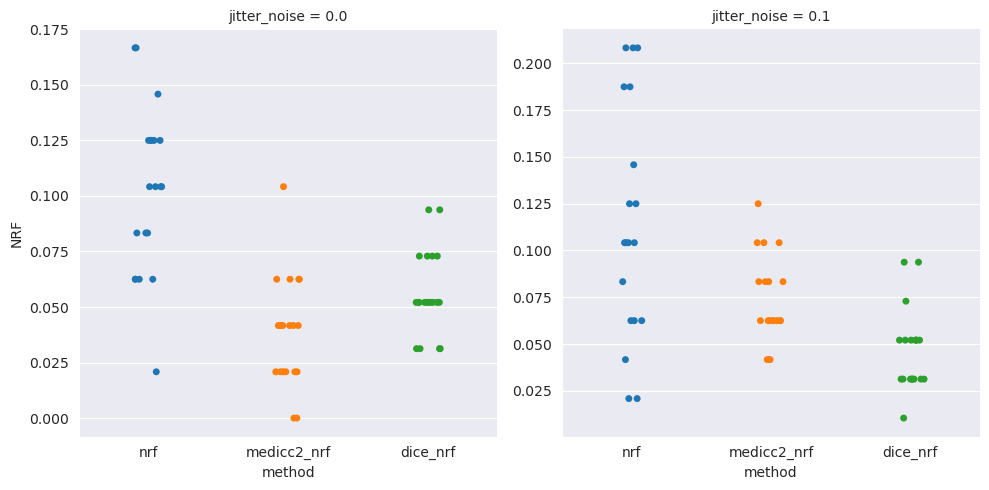

In [113]:
Dxdf = df[df['dataset'].apply(lambda x: x.startswith("Dx"))]
Dxdf = pd.melt(Dxdf,
    id_vars=['seed', 'jitter_noise', 'boundary_noise', 'dataset', 'mean_cnas_per_edge', 'n_clones', 'cn_length_mean'],
    value_vars=['nrf', 'medicc2_nrf', 'dice_nrf'],
    var_name='method',
    value_name='NRF'
)
g = sns.catplot(Dxdf, x='method', y='NRF', hue='method', col='jitter_noise', sharey=False)


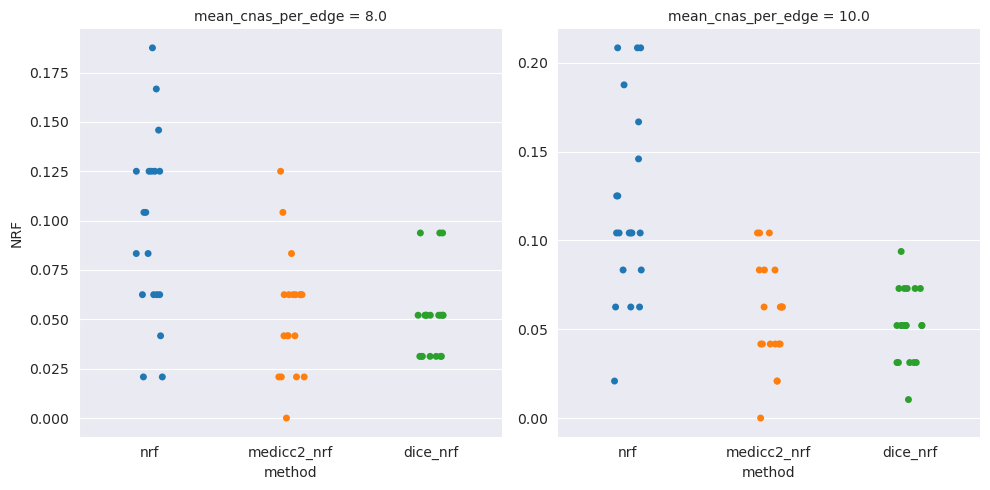

In [114]:
Dxdf = df[df['dataset'].apply(lambda x: x.startswith("Dx"))]
Dxdf = pd.melt(Dxdf,
    id_vars=['seed', 'jitter_noise', 'boundary_noise', 'dataset', 'mean_cnas_per_edge', 'n_clones', 'cn_length_mean'],
    value_vars=['nrf', 'medicc2_nrf', 'dice_nrf'],
    var_name='method',
    value_name='NRF'
)
g = sns.catplot(Dxdf, x='method', y='NRF', hue='method', col='mean_cnas_per_edge', sharey=False)


## F1 score